In [ ]:
import math
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
from torch.utils.data import Dataset
from torchvision import transforms as T

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
class CIFARDataset(Dataset):
  def __init__(self, images, labels, mode, transform):
    self.transform = transform

    if mode == 'train':
      self.images = images[0: 40000, :, :, :]
      self.labels = labels[0: 40000]
      self.mode = 'train'
      # Your code here. If training, use examples [0,40000) of the
      # entire dataset

    elif mode == 'val':
      self.images = images[40000: 50000, :, :, :]
      self.labels = labels[40000: 50000]
      self.mode = 'val'
      pass # Your code here. If validation, use examples [40,000-50,000)
      # of the entire dataset

    elif mode == 'test':
      self.images = images[50000: 60000, :, :, :]
      self.labels = labels[50000: 60000]
      self.mode = 'test'
      pass # Your code here. If testing, use examples [50,000-60,000) of the
      # entire dataset

    else:
      raise ValueError('Invalid mode!')

  def __getitem__(self, idx):

    image = self.images[idx]
    label = self.labels[idx]

    label = torch.tensor(label, dtype=torch.long)
    if self.transform:
      image = self.transform(image)
    return image, label

  def __len__(self):
    return len(self.labels)

cuda:0


In [ ]:
cifar = np.load('/content/drive/MyDrive/CIFAR.npz')
X, y, label_names = cifar['X'], cifar['y'] * 1.0, cifar['label_names']
print("Read in CIFAR10 dataset with %d examples, and labels:\n %s" % (X.shape[0], label_names))
print(X.shape)
batch_size = 64

transform = T.Compose([T.ToTensor(), T.RandomHorizontalFlip(), T.RandomAffine(degrees = [-5, 5], scale = [.8, 1.2]), T.ColorJitter(brightness = [.8, 1.2], saturation = [.8, 1.2])]) # Add transforms.
train_dataset = CIFARDataset(X, y, "train", transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)

transform = T.ToTensor()
val_dataset = CIFARDataset(X, y, "val", transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=1)

transform = T.ToTensor()
test_dataset = CIFARDataset(X, y, "test", transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=1)

Read in CIFAR10 dataset with 60000 examples, and labels:
 ['airplane' 'automobile' 'bird' 'cat' 'deer' 'dog' 'frog' 'horse' 'ship'
 'truck']
(60000, 32, 32, 3)


In [ ]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_relu_stack = nn.Sequential(
            nn.LazyConv2d(50, 3, padding = 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.LazyConv2d(100, 3, padding = 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.LazyConv2d(100, 3, padding = 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.LazyConv2d(100, 3, padding = 1), nn.ReLU(),
        )
    self.lin_relu_stack = nn.Sequential(
        nn.LazyLinear(100), nn.ReLU(),
        nn.LazyLinear(10)
    )

  def forward(self, x):
    x = self.conv_relu_stack(x)
    x = x.reshape((batch_size, -1))
    x = self.lin_relu_stack(x)
    return x

NameError: name 'nn' is not defined

### 2d/2e: Implement the training loop, and train your model.

In [ ]:

model = Model()
model.to(device)
learning_rate = 1e-4
epochs = 15
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (x, y) in enumerate(dataloader):
        X, yy = x.to(device), y.to(device)
        optimizer.zero_grad()
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, yy)

        # Backpropagation
        loss.backward()
        optimizer.step()


        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



In [ ]:
acc = []
lost = []
def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in dataloader:
          X, yy = x.to(device), y.to(device)
          if X.shape[0] != 64:
            break
          pred = model(X)
          test_loss += loss_fn(pred, yy).item()
          correct += (pred.argmax(1) == yy).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    acc.append((100*correct))
    lost.append(test_loss)
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
acc = []
lost = []
for t in range(epochs):
  train_loop(train_dataloader, model, loss_fn, optimizer)
  print("Epoch number: " + str(t+1))
  test_loop(val_dataloader, model, loss_fn)
  torch.save({
      'epoch': t,
      'model_state_dict':model.state_dict(),
  }, str(t) + '.tar')


loss: 2.310290  [   64/40000]
loss: 2.114055  [ 6464/40000]
loss: 2.019115  [12864/40000]
loss: 1.991513  [19264/40000]
loss: 1.872869  [25664/40000]
loss: 1.723864  [32064/40000]
loss: 1.678157  [38464/40000]
Epoch number: 1
Test Error: 
 Accuracy: 35.8%, Avg loss: 1.725761 

loss: 1.900661  [   64/40000]
loss: 1.717744  [ 6464/40000]
loss: 1.703034  [12864/40000]
loss: 1.664282  [19264/40000]
loss: 1.709129  [25664/40000]
loss: 1.488516  [32064/40000]
loss: 1.488624  [38464/40000]
Epoch number: 2
Test Error: 
 Accuracy: 40.5%, Avg loss: 1.609205 

loss: 2.003042  [   64/40000]
loss: 1.539411  [ 6464/40000]
loss: 1.660267  [12864/40000]
loss: 1.419236  [19264/40000]
loss: 1.573204  [25664/40000]
loss: 1.562303  [32064/40000]
loss: 1.404272  [38464/40000]
Epoch number: 3
Test Error: 
 Accuracy: 43.3%, Avg loss: 1.544765 

loss: 1.631478  [   64/40000]
loss: 1.595448  [ 6464/40000]
loss: 1.520589  [12864/40000]
loss: 1.530980  [19264/40000]
loss: 1.431693  [25664/40000]
loss: 1.660762  

In [ ]:

model.eval()
size = np.array([0]*10, dtype = "float64")
num_batches = len(test_dataloader)
test_loss = 0
correct = np.array([0]*10, dtype = "float64")
confusion = np.zeros((10, 10))
totpred = [[[]for _ in range(10)]for _ in range(10)]
counter = 0

with torch.no_grad():
    for x, y in test_dataloader:
      X, yy = x.to(device), y.to(device)
      if X.shape[0] != 64:
        break
      pred = model(X)
      for label, prediction in zip(yy, pred.argmax(1)):
        if label == prediction:
          correct[label] += 1
        if label != test_dataset[counter][1]:
          print(counter)
        confusion[label][prediction] += 1
        size[label] += 1
        (totpred[label][prediction]).append(counter)
        counter += 1


      test_loss += loss_fn(pred, yy).item()

test_loss /= num_batches

In [ ]:
labs = 100*correct/size
print(f"overall accuracy: {100*sum(correct)/sum(size):>0.1f}%")
for i in range(10):
  print(f"{label_names[i]}: {labs[i]:>0.1f}%")
worst_y = np.argmin(labs)



overall accuracy: 61.4%
airplane: 63.8%
automobile: 63.9%
bird: 49.1%
cat: 39.7%
deer: 53.4%
dog: 57.0%
frog: 67.7%
horse: 73.6%
ship: 75.6%
truck: 70.4%


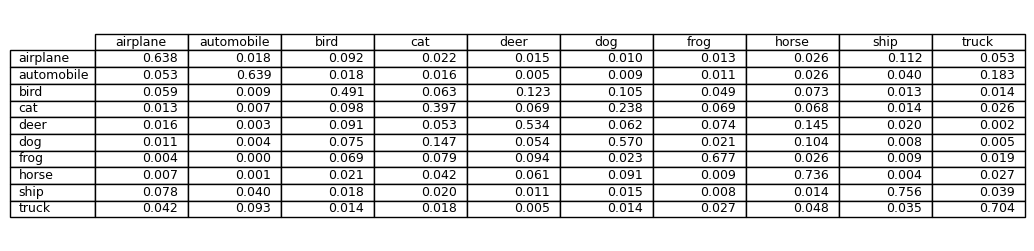

In [ ]:
c = [[f"{confusion[i][j]/size[i]:>0.3f}"for j in range(10)] for i in range(10)]
plt.figure(figsize=(12, 3))
conf = plt.table(cellText = c, colLabels = label_names, rowLabels = label_names, loc = 'center')
conf.set_fontsize(21)
conf.set_snap(True)
plt.axis(False)
plt.show()
confusion[worst_y][worst_y] = 0
worst_pred = np.argmax(confusion[worst_y])


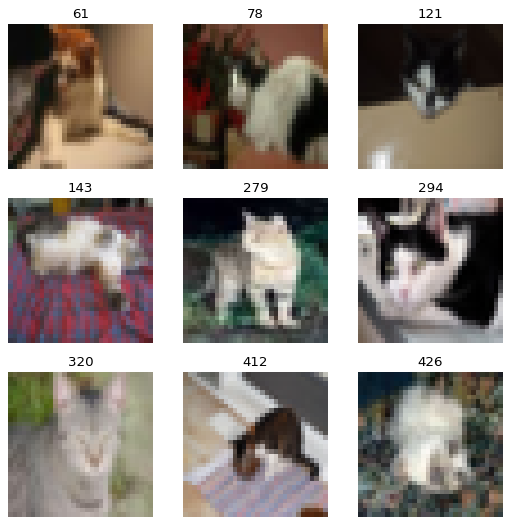

In [ ]:
images = []
titles = []
for i in range(9):
  images.append(test_dataset[totpred[worst_y][worst_pred][i]][0].numpy().transpose(1, 2, 0))
  titles.append(totpred[worst_y][worst_pred][i])
show_image_subplot(images, 3, 3, titles, size = (8, 8))
